# M3/S1: LLM Benchmark — Token-Level Classification (Zero-Shot & Few-Shot)

**Cíl:** Evaluovat LLM (Gemma 3 27B) v režimu Zero-Shot a Few-Shot na detekci subjektivních/hodnotících slov (LJMPNIK) na úrovni tokenů.

**Metodologie:**
- Inference běží na **všech tokenech** (`filter_type='none'`), aby LLM vidělo plný kontext.
- Evaluace používá **post-hoc POS filtraci** (none / mild / aggressive) pro férové srovnání s M2/S1 modely.

**Strategie:**
- `zeroshot` — Přímý prompt bez příkladů
- `fewshot` — Prompt se 3 ukázkovými příklady

**Srovnání:**
- Dummy (Majority) — absolutní baseline
- Nejlepší M2/S1 model (supervised, z `M2_S1_experiment_results_v3.csv`)
- Gemma 3 (27B) — Zero-Shot & Few-Shot LLM

## 1. Setup & Imports

In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, average_precision_score
)
from sklearn.dummy import DummyClassifier

# Auto-reload modules for development
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Add src to path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

# Import custom modules
import config
import data_splitting
import models
import visualization
import evaluation
from llm_client import LLMClassifier

# Setup visualization style
visualization.setup_style()

print(f"\u2705 Setup complete. Data dir: {config.DATA_DIR}")

⚙️ Configuration loaded. Device: cpu


2026-03-13 17:14:30,383 - INFO - Visualization style applied (ggplot + Set2).


✅ Setup complete. Data dir: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data


## 2. Načtení Testovacích Dat (Token-Level, All POS)

Načítáme **všechny tokeny** (`filter_type='none'`), aby LLM vidělo plný kontext věty.
Evaluace s post-hoc POS filtrací zajistí férové srovnání s M2 modely (aggressive filtr).

In [2]:
# Načtení Baseline scénáře (S1a) na token úrovni — VŠECHNY POS tagy
data = data_splitting.get_train_val_test_splits(
    scenario='baseline',
    level='token',
    filter_type='none',  # Všechny tokeny — post-hoc filtrace v evaluaci
    random_state=42
)

# Extrakce test setu
df_test = data['meta_test'].copy()
df_test['true_label'] = data['y_test']

# Rekonstrukce kontextu věty z tokenů (seskupení podle sentence_id)
sentence_texts = df_test.groupby('sentence_id')['form'].apply(lambda x: ' '.join(x)).to_dict()
df_test['sentence_context'] = df_test['sentence_id'].map(sentence_texts)

print(f"📊 Test Set Size: {len(df_test)} tokens (all POS)")
print(f"   Unique sentences: {df_test['sentence_id'].nunique()}")
print(f"   Label distribution: L0={sum(df_test['true_label']==0)}, L1={sum(df_test['true_label']==1)}")
print(f"   Ratio: {sum(df_test['true_label']==0)/max(sum(df_test['true_label']==1),1):.1f}:1")
print(f"   POS tags present: {sorted(df_test['pos'].unique())}")
display(df_test.head(5))

2026-03-13 17:14:30,600 - INFO - 📊 Preparing scenario: baseline (token level, none filter)
2026-03-13 17:14:31,223 - INFO - ✅ Loaded 17557 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\gold_tokens.pkl
2026-03-13 17:14:34,249 - INFO - ✅ Loaded 78991 rows from C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\data\processed\silver_tokens.pkl
2026-03-13 17:14:34,265 - INFO - Splitting 520 documents: 104 test, 41 val, 375 train
2026-03-13 17:14:34,274 - INFO - ✅ Document-level split completed:
2026-03-13 17:14:34,276 - INFO -    Train: 376 docs, 4369 samples
2026-03-13 17:14:34,277 - INFO -    Val:   41 docs, 454 samples
2026-03-13 17:14:34,278 - INFO -    Test:  103 docs, 1246 samples
2026-03-13 17:14:34,284 - INFO -    ✓ No document leakage detected between splits
2026-03-13 17:14:34,286 - INFO - ✅ Scenario data prepared:
2026-03-13 17:14:34,288 - INFO -    Train: 4369 samples (L0: 1470, L1: 2899)
2026-03-13 17:14:34,

📊 Test Set Size: 1246 tokens (all POS)
   Unique sentences: 103
   Label distribution: L0=1185, L1=61
   Ratio: 19.4:1
   POS tags present: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB']


,document_id,sentence_id,token_id,form,pos,true_label,sentence_context
66,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_0,Tempo,NOUN,0,Tempo výstavby nových bytů je žalostné .
67,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_1,výstavby,NOUN,0,Tempo výstavby nových bytů je žalostné .
68,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_2,nových,ADJ,0,Tempo výstavby nových bytů je žalostné .
69,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_3,bytů,NOUN,0,Tempo výstavby nových bytů je žalostné .
70,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_4,je,AUX,0,Tempo výstavby nových bytů je žalostné .


## 3. Definice LLM Modelu a Cesty

In [3]:
MODELS_TO_TEST = [
    {
        'id': 'gemma-3-27b',
        'provider': 'gemini',
        'model_name': 'gemma-3-27b-it',
        'display_name': 'Gemma 3 (27B)'
    }
]

# Cesta pro ukládání výsledků (průběžné predikce)
RESULTS_FILE = config.RESULTS_DIR / "M3_S1_LLM_predictions.csv"

print(f"\U0001f4be Results file: {RESULTS_FILE}")
print(f"\U0001f916 Models to test: {[m['display_name'] for m in MODELS_TO_TEST]}")


# ==========================================================
# Definice strategií
# ==========================================================
PROMPT_STRATEGIES = ['zeroshot', 'fewshot']

💾 Results file: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_LLM_predictions.csv
🤖 Models to test: ['Gemma 3 (27B)']


## 4. Inference Loop (Zero-Shot & Few-Shot Token Classification)

Pro každý token sestavíme prompt, který obsahuje:
1. Celou větu jako kontext
2. Konkrétní slovo k posouzení

**Strategie:**
- `zeroshot`: Přímý prompt (stejný jako předchozí verze)
- `fewshot`: Prompt s 3 ukázkovými příklady pro snížení over-senzitivity

**Migrace dat:** Existující sloupec `pred_gemma-3-27b` se automaticky přejmenuje na `pred_gemma-3-27b_zeroshot`.

In [ ]:
%%script false

# ==========================================================
# 1. Migrace existujícího CSV (záchrana dat)
# ==========================================================
if RESULTS_FILE.exists():
    df_results = pd.read_csv(RESULTS_FILE)
    print(f"♻️ Načteny předchozí výsledky: {len(df_results)} řádků.")
else:
    df_results = df_test.copy()
    print("🆕 Žádné předchozí výsledky — začínáme od nuly.")

# ==========================================================
# 2. Inference smyčka: strategie × modely
# ==========================================================
for strategy in PROMPT_STRATEGIES:
    print(f"\n{'='*60}")
    print(f"📋 STRATEGIE: {strategy.upper()}")
    print(f"{'='*60}")
    
    for model_cfg in MODELS_TO_TEST:
        model_id = model_cfg['id']
        col_name = f"pred_{model_id}_{strategy}"
        
        print(f"\n🚀 {model_cfg['display_name']} [{strategy}]...")
        
        # Inicializace sloupce
        if col_name not in df_results.columns:
            df_results[col_name] = np.nan
        
        # Přeskočení hotových řádků
        missing_mask = df_results[col_name].isna()
        indices_to_process = df_results[missing_mask].index
        
        if len(indices_to_process) == 0:
            print(f"   ⏭️ Všechny predikce existují — přeskakuji.")
            continue
        
        print(f"   → Processing {len(indices_to_process)}/{len(df_results)} tokens...")
        
        try:
            clf = LLMClassifier(
                provider=model_cfg['provider'],
                model_name=model_cfg['model_name']
            )
        except Exception as e:
            print(f"   ❌ Skipped model {model_id}: {e}")
            continue
        
        for i, idx in enumerate(tqdm(indices_to_process, desc=f"{model_id} [{strategy}]")):
            token_to_check = df_results.loc[idx, 'form']
            sentence_context = df_results.loc[idx, 'sentence_context']
            
            # ---- Dynamický prompt podle strategie ----
            if strategy == 'fewshot':
                query_text = (
                    f"Tvým úkolem je analyzovat konkrétní slovo v textu a určit, "
                    f"zda představuje porušení novinářské objektivity "
                    f"(subjektivní, hodnotící nebo emocionálně zabarvený výraz).\n\n"
                    f"PŘÍKLADY:\n"
                    f"Věta: 'Prezident dnes odletěl do Paříže.' | Slovo: 'odletěl' | Odpověď: 0\n"
                    f"Věta: 'Vláda a odbory se dohodly na kompromisu.' | Slovo: 'a' | Odpověď: 0\n"
                    f"Věta: 'Tempo výstavby nových bytů je naprosto žalostné.' | Slovo: 'žalostné' | Odpověď: 1\n\n"
                    f"NYNÍ TVŮJ ÚKOL:\n"
                    f"Věta: '{sentence_context}' | Slovo: '{token_to_check}'\n"
                    f"Odpověď (POUZE číslo 0 nebo 1):"
                )
            else:  # zeroshot
                query_text = (
                    f"Analyzuj následující větu: '{sentence_context}'. "
                    f"Představuje konkrétně slovo '{token_to_check}' v tomto kontextu "
                    f"subjektivní, hodnotící nebo emocionálně zabarvený výraz "
                    f"(porušení novinářské objektivity)? "
                    f"Odpověz POUZE jedním číslem: 1 (ano, toto slovo tvoří bias) "
                    f"nebo 0 (ne, slovo je neutrální)."
                )
            
            prediction = clf.predict(query_text, retries=5, sleep_time=5)
            
            if prediction is not None:
                df_results.loc[idx, col_name] = prediction
            else:
                print(f"   ⚠️ Failed: index {idx} (token='{token_to_check}')")
            
            # Crash-safe ukládání po každém tokenu
            df_results.to_csv(RESULTS_FILE, index=False)
            
            # Rate-limit brzda
            time.sleep(2.5)
        
        print(f"   ✅ {model_cfg['display_name']} [{strategy}] hotovo.")

df_results.to_csv(RESULTS_FILE, index=False)
print(f"\n🏁 Všechny benchmarky dokončeny. Uloženo: {RESULTS_FILE}")
display(df_results.head())

🆕 Žádné předchozí výsledky — začínáme od nuly.

📋 STRATEGIE: ZEROSHOT

🚀 Gemma 3 (27B) [zeroshot]...
   → Processing 1246/1246 tokens...


gemma-3-27b [zeroshot]:   0%|          | 0/1246 [00:00<?, ?it/s]

   ✅ Gemma 3 (27B) [zeroshot] hotovo.

📋 STRATEGIE: FEWSHOT

🚀 Gemma 3 (27B) [fewshot]...
   → Processing 1246/1246 tokens...


gemma-3-27b [fewshot]:   0%|          | 0/1246 [00:00<?, ?it/s]

   ✅ Gemma 3 (27B) [fewshot] hotovo.

🏁 Všechny benchmarky dokončeny. Uloženo: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_LLM_predictions.csv


,document_id,sentence_id,token_id,form,pos,true_label,sentence_context,pred_gemma-3-27b_zeroshot,pred_gemma-3-27b_fewshot
66,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_0,Tempo,NOUN,0,Tempo výstavby nových bytů je žalostné .,1.0,1.0
67,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_1,výstavby,NOUN,0,Tempo výstavby nových bytů je žalostné .,1.0,1.0
68,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_2,nových,ADJ,0,Tempo výstavby nových bytů je žalostné .,1.0,1.0
69,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_3,bytů,NOUN,0,Tempo výstavby nových bytů je žalostné .,1.0,0.0
70,gold_doc_0003,gold_doc_0003_target,gold_doc_0003_target_tok_4,je,AUX,0,Tempo výstavby nových bytů je žalostné .,1.0,1.0


## 5. Evaluace s Post-Hoc POS Filtrací

**Zásadní krok:** Metriky počítáme pro 3 POS filtry (none / mild / aggressive), aby srovnání s M2 bylo férové.

| Filtr | Definice |
|-------|----------|
| `none` | Všechny tokeny |
| `mild` | Vyloučí ADP, CCONJ, SCONJ, PUNCT, SYM |
| `aggressive` | Ponechá pouze NOUN, ADJ, VERB, ADV |

Pro každou kombinaci **(strategie × filtr)** počítáme AUPRC, F1, Precision, Recall.

In [5]:
# ==========================================
# 0. Načtení predikcí z CSV
# ==========================================
results_path = config.RESULTS_DIR / "M3_S1_LLM_predictions.csv"

try:
    df_results = pd.read_csv(results_path)
    print(f"✅ Predikce načteny ze souboru ({len(df_results)} řádků).")
except FileNotFoundError:
    raise FileNotFoundError(f"❌ Soubor s predikcemi nebyl nalezen: {results_path}")

# ==========================================
# 1. Definice Post-Hoc POS filtrů
# ==========================================
POS_FILTER_DEFS = {
    'none': lambda df: df.index,  # všechny řádky
    'mild': lambda df: df[~df['pos'].isin(['ADP', 'CCONJ', 'SCONJ', 'PUNCT', 'SYM'])].index,
    'aggressive': lambda df: df[df['pos'].isin(config.POS_ALLOWED_AGGRESSIVE)].index,
}

print(f"📊 Definováno {len(POS_FILTER_DEFS)} POS filtrů: {list(POS_FILTER_DEFS.keys())}")
for fname, ffunc in POS_FILTER_DEFS.items():
    n = len(ffunc(df_results))
    print(f"   {fname}: {n} tokenů ({n/len(df_results)*100:.1f}%)")

# ==========================================
# 2. Identifikace predikčních sloupců a strategií
# ==========================================
pred_cols = [c for c in df_results.columns if c.startswith('pred_')]
print(f"\n🔍 Nalezené predikční sloupce: {pred_cols}")

metrics_records = []

# ==========================================
# 3. Výpočet metrik: strategie × filtr
# ==========================================
print(f"\n{'='*70}")
print("📊 VÝPOČET METRIK: strategie × POS filtr")
print(f"{'='*70}")

for col in pred_cols:
    # Parsování názvu: pred_{model}_{strategy}
    parts = col.replace('pred_', '').rsplit('_', 1)
    if len(parts) == 2:
        model_name, strategy = parts
    else:
        model_name, strategy = parts[0], 'zeroshot'
    
    # Najdi display name z MODELS_TO_TEST
    display_name = model_name
    for m in MODELS_TO_TEST:
        if m['id'] == model_name:
            display_name = m['display_name']
            break
    
    strategy_label = 'Zero-Shot' if strategy == 'zeroshot' else 'Few-Shot'
    
    for filter_name, filter_func in POS_FILTER_DEFS.items():
        filter_label = filter_name.capitalize()
        
        # Aplikace POS filtru
        valid_idx = filter_func(df_results)
        df_filtered = df_results.loc[valid_idx].dropna(subset=[col, 'true_label']).copy()
        
        if len(df_filtered) == 0:
            print(f"   ⚠️ {display_name} ({strategy_label}, {filter_label}): žádné validní predikce")
            continue
        
        y_true = df_filtered['true_label'].astype(int)
        y_pred = df_filtered[col].astype(int)
        
        row_name = f"{display_name} ({strategy_label}, {filter_label})"
        
        metrics_records.append({
            'model': row_name,
            'model_base': display_name,
            'strategy': strategy,
            'filter': filter_name,
            'n_tokens': len(df_filtered),
            'n_positive': int(y_true.sum()),
            'auprc': average_precision_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
        })
        
        r = metrics_records[-1]
        print(f"   🤖 {row_name}: F1={r['f1']:.4f}, AUPRC={r['auprc']:.4f}, "
              f"P={r['precision']:.4f}, R={r['recall']:.4f} (n={r['n_tokens']})")

# ==========================================
# 4. Dummy Classifier (pro každý filtr)
# ==========================================
print(f"\n{'='*70}")
print("📦 DUMMY BASELINE (Majority) × POS filtr")
print(f"{'='*70}")

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
# Fit na train data (features irrelevant for majority)
dummy_clf.fit(np.zeros((len(data['y_train']), 1)), data['y_train'])

for filter_name, filter_func in POS_FILTER_DEFS.items():
    filter_label = filter_name.capitalize()
    valid_idx = filter_func(df_results)
    df_filtered = df_results.loc[valid_idx].dropna(subset=['true_label']).copy()
    
    y_true = df_filtered['true_label'].astype(int).values
    y_pred_dummy = dummy_clf.predict(np.zeros((len(y_true), 1)))
    
    row_name = f"Dummy ({filter_label})"
    
    metrics_records.append({
        'model': row_name,
        'model_base': 'Dummy (Majority)',
        'strategy': 'dummy',
        'filter': filter_name,
        'n_tokens': len(df_filtered),
        'n_positive': int(y_true.sum()),
        'auprc': average_precision_score(y_true, y_pred_dummy),
        'f1': f1_score(y_true, y_pred_dummy, zero_division=0),
        'precision': precision_score(y_true, y_pred_dummy, zero_division=0),
        'recall': recall_score(y_true, y_pred_dummy, zero_division=0),
    })
    
    r = metrics_records[-1]
    print(f"   📦 {row_name}: F1={r['f1']:.4f}, AUPRC={r['auprc']:.4f} (n={r['n_tokens']})")

# ==========================================
# 5. Uložení metrik
# ==========================================
df_llm_metrics = pd.DataFrame(metrics_records)
metrics_path = config.RESULTS_DIR / "M3_S1_LLM_Metrics.csv"
df_llm_metrics.to_csv(metrics_path, index=False)

print(f"\n💾 Metriky uloženy do: {metrics_path}")
print(f"\n📊 Přehled všech {len(df_llm_metrics)} kombinací:")
display(df_llm_metrics[['model', 'filter', 'n_tokens', 'auprc', 'f1', 'precision', 'recall']])

✅ Predikce načteny ze souboru (1246 řádků).
📊 Definováno 3 POS filtrů: ['none', 'mild', 'aggressive']
   none: 1246 tokenů (100.0%)
   mild: 923 tokenů (74.1%)
   aggressive: 741 tokenů (59.5%)

🔍 Nalezené predikční sloupce: ['pred_gemma-3-27b_zeroshot', 'pred_gemma-3-27b_fewshot']

📊 VÝPOČET METRIK: strategie × POS filtr
   🤖 Gemma 3 (27B) (Zero-Shot, None): F1=0.1822, AUPRC=0.0902, P=0.1036, R=0.7541 (n=1246)
   🤖 Gemma 3 (27B) (Zero-Shot, Mild): F1=0.2278, AUPRC=0.1170, P=0.1343, R=0.7500 (n=923)
   🤖 Gemma 3 (27B) (Zero-Shot, Aggressive): F1=0.2410, AUPRC=0.1297, P=0.1399, R=0.8696 (n=741)
   🤖 Gemma 3 (27B) (Few-Shot, None): F1=0.2105, AUPRC=0.1025, P=0.1232, R=0.7213 (n=1246)
   🤖 Gemma 3 (27B) (Few-Shot, Mild): F1=0.2614, AUPRC=0.1330, P=0.1599, R=0.7167 (n=923)
   🤖 Gemma 3 (27B) (Few-Shot, Aggressive): F1=0.2806, AUPRC=0.1520, P=0.1681, R=0.8478 (n=741)

📦 DUMMY BASELINE (Majority) × POS filtr
   📦 Dummy (None): F1=0.0000, AUPRC=0.0490 (n=1246)
   📦 Dummy (Mild): F1=0.0000, AU

,model,filter,n_tokens,auprc,f1,precision,recall
0,"Gemma 3 (27B) (Zero-Shot, None)",none,1246,0.090166,0.182178,0.103604,0.754098
1,"Gemma 3 (27B) (Zero-Shot, Mild)",mild,923,0.116998,0.227848,0.134328,0.750000
2,"Gemma 3 (27B) (Zero-Shot, Aggressive)",aggressive,741,0.129715,0.240964,0.139860,0.869565
3,"Gemma 3 (27B) (Few-Shot, None)",none,1246,0.102545,0.210526,0.123249,0.721311
4,"Gemma 3 (27B) (Few-Shot, Mild)",mild,923,0.132978,0.261398,0.159851,0.716667
5,"Gemma 3 (27B) (Few-Shot, Aggressive)",aggressive,741,0.151969,0.280576,0.168103,0.847826
6,Dummy (None),none,1246,0.048957,0.000000,0.000000,0.000000
7,Dummy (Mild),mild,923,0.065005,0.000000,0.000000,0.000000
8,Dummy (Aggressive),aggressive,741,0.062078,0.000000,0.000000,0.000000


## 6. Férové srovnání s nejlepším M2/S1 modelem (Aggressive filtr)

Klíčové srovnání: LLM (Zero-Shot & Few-Shot) na **aggressive** filtru vs. nejlepší M2/S1 supervised model (SVM).
Post-hoc filtrace zajišťuje, že LLM je hodnoceno na **stejné podmnožině tokenů** jako M2.

✅ Nejlepší M2/S1 Baseline model nalezen!
🏆 SVM (RBF) | AUPRC: 0.7038

📊 FÉROVÉ SROVNÁNÍ — Aggressive POS filtr

Model                                            AUPRC       F1     Prec      Rec
--------------------------------------------------------------------------------
Gemma 3 (27B) (Zero-Shot, Aggressive)           0.1297   0.2410   0.1399   0.8696
Gemma 3 (27B) (Few-Shot, Aggressive)            0.1520   0.2806   0.1681   0.8478
Dummy (Aggressive)                              0.0621   0.0000   0.0000   0.0000
SVM (RBF) (M2/S1 Supervised, Aggressive)        0.7038   0.6667   0.5806   0.7826

📊 Vykresluji porovnání...


2026-03-13 20:29:05,229 - INFO - 💾 Saved LLM comparison plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_LLM_vs_M2_aggressive_plot.png


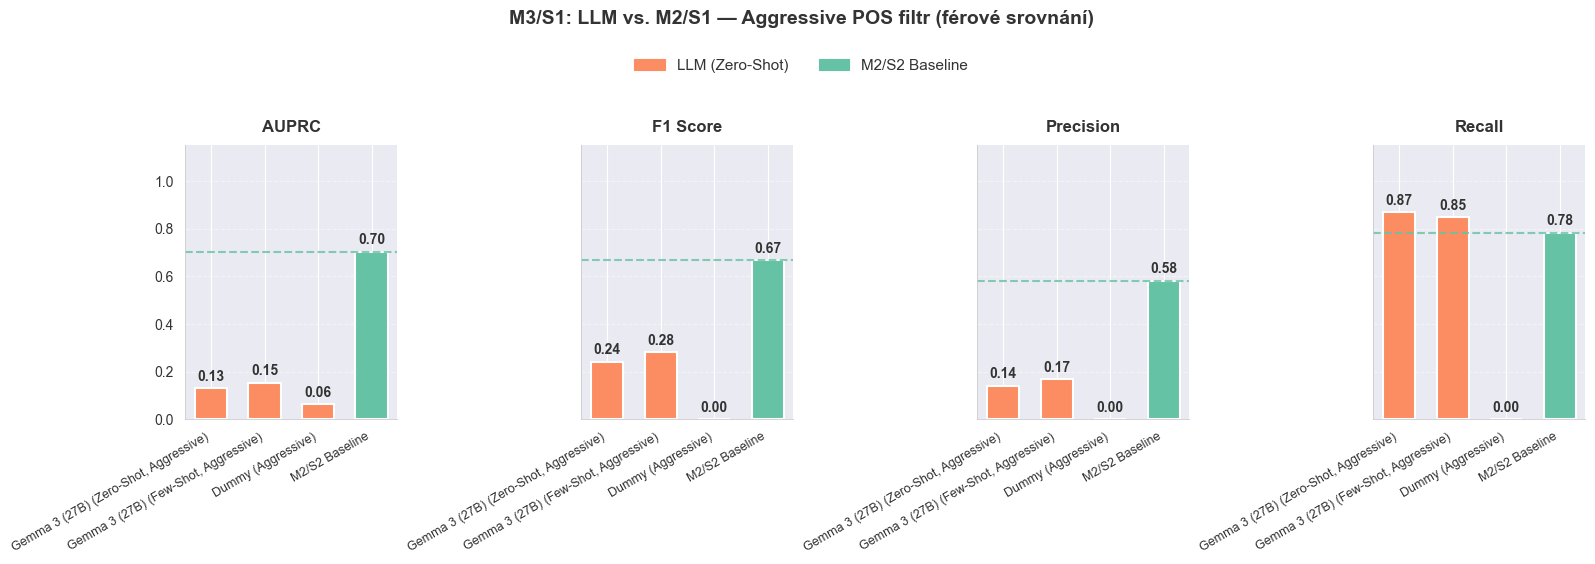

In [ ]:
# ==========================================
# 1. Načtení nejlepšího M2/S1 modelu (baseline, aggressive filtr)
# ==========================================
M2_S1_path = config.RESULTS_DIR / "M2_S1_experiment_results_v3.csv"
TARGET_METRIC = 'test_auprc'

try:
    df_m2_results = pd.read_csv(M2_S1_path)
    
    # Filtrujeme baseline scénář (S1a) — aggressive filtr
    df_m2_baseline = df_m2_results[df_m2_results['id'] == 'S1a'].copy()
    
    # Nejlepší model podle AUPRC
    df_m2_best = df_m2_baseline.loc[df_m2_baseline[TARGET_METRIC].idxmax()].to_frame().T
    
    best_m2_name = df_m2_best['model'].iloc[0]
    best_m2_auprc = df_m2_best[TARGET_METRIC].iloc[0]
    
    print(f"✅ Nejlepší M2/S1 Baseline model nalezen!")
    print(f"🏆 {best_m2_name} | AUPRC: {best_m2_auprc:.4f}")

except FileNotFoundError:
    print(f"❌ Soubor s M2/S1 výsledky nebyl nalezen: {M2_S1_path}")
    df_m2_best = None

# ==========================================
# 2. Srovnávací tabulka (pouze Aggressive filtr)
# ==========================================
df_aggressive = df_llm_metrics[df_llm_metrics['filter'] == 'aggressive'].copy()

print(f"\n{'='*70}")
print("📊 FÉROVÉ SROVNÁNÍ — Aggressive POS filtr")
print(f"{'='*70}")
print(f"\n{'Model':<45} {'AUPRC':>8} {'F1':>8} {'Prec':>8} {'Rec':>8}")
print("-" * 80)

for _, row in df_aggressive.iterrows():
    print(f"{row['model']:<45} {row['auprc']:>8.4f} {row['f1']:>8.4f} "
          f"{row['precision']:>8.4f} {row['recall']:>8.4f}")

if df_m2_best is not None:
    b = df_m2_best.iloc[0]
    m2_label = f"{b['model']} (M2/S1 Supervised, Aggressive)"
    print(f"{m2_label:<45} {b['test_auprc']:>8.4f} {b['test_f1']:>8.4f} "
          f"{b['test_prec']:>8.4f} {b['test_rec']:>8.4f}")

# ==========================================
# 3. Vykreslení srovnání LLM vs M2/S1
# ==========================================
metrics_to_plot = ['auprc', 'f1', 'precision', 'recall']

print("\n📊 Vykresluji porovnání...")
visualization.plot_llm_vs_m2_comparison(
    df_llm_metrics=df_aggressive,
    df_m2_best=df_m2_best,
    metrics=metrics_to_plot,
    title="M3/S1: LLM vs. M2/S1 — Aggressive POS filtr (férové srovnání)",
    save_path=config.RESULTS_DIR / "M3_S1_LLM_vs_M2_aggressive_plot.png"
)

### Master Overview (plot_experiment_results)

Sjednocený přehled: LLM (Zero-Shot & Few-Shot) × POS filtry vs. M2/S1 Supervised vs. Dummy.
Vizualizace férovosti: **Aggressive filtr** je klíčový pro srovnání s M2.

📊 Master Overview DataFrame:


,model,test_f1,test_auprc,test_prec,test_rec
0,"Gemma 3 (27B) (Zero-Shot, None)",0.182178,0.090166,0.103604,0.754098
1,"Gemma 3 (27B) (Zero-Shot, Mild)",0.227848,0.116998,0.134328,0.750000
2,"Gemma 3 (27B) (Zero-Shot, Aggressive)",0.240964,0.129715,0.139860,0.869565
3,"Gemma 3 (27B) (Few-Shot, None)",0.210526,0.102545,0.123249,0.721311
4,"Gemma 3 (27B) (Few-Shot, Mild)",0.261398,0.132978,0.159851,0.716667
5,"Gemma 3 (27B) (Few-Shot, Aggressive)",0.280576,0.151969,0.168103,0.847826
6,Dummy (None),0.000000,0.048957,0.000000,0.000000
7,Dummy (Mild),0.000000,0.065005,0.000000,0.000000
8,Dummy (Aggressive),0.000000,0.062078,0.000000,0.000000
9,SVM (RBF) (M2/S1),0.666667,0.703809,0.580645,0.782609


2026-03-13 20:29:05,723 - INFO - Saved experiment results plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_experiment_overview_f1.png


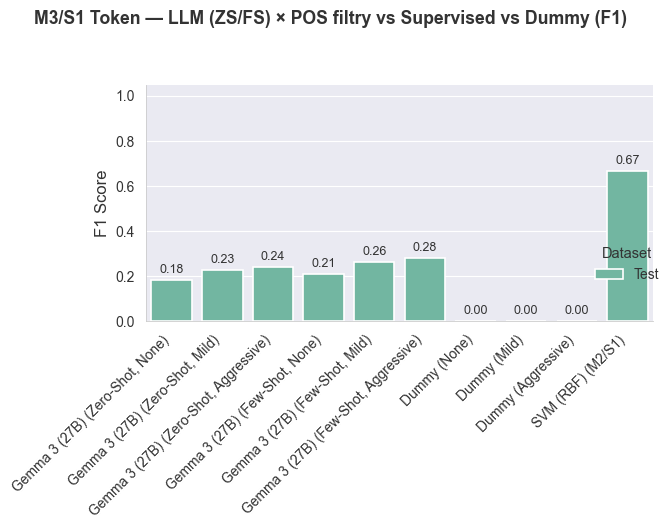

2026-03-13 20:29:06,069 - INFO - Saved experiment results plot to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_experiment_overview_auprc.png


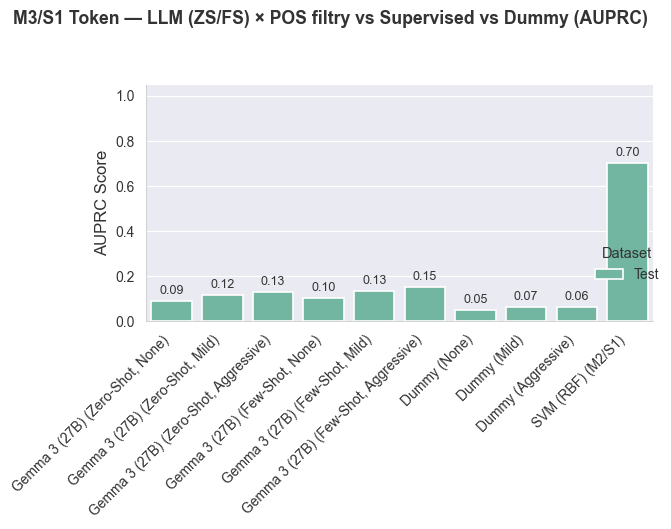

In [7]:
# ==========================================
# Sestavení sjednoceného DataFrame pro plot_experiment_results
# ==========================================
rows = []

# LLM metriky (všechny kombinace strategie × filtr)
for _, row in df_llm_metrics.iterrows():
    rows.append({
        'id': 'M3_S1',
        'scenario': f"{row.get('strategy', 'unknown')}_{row.get('filter', 'unknown')}",
        'scenario_name': f"{row.get('strategy', '').title()} ({row.get('filter', '').title()})",
        'model': row['model'],
        'test_f1': row['f1'], 'test_auprc': row['auprc'],
        'test_prec': row['precision'], 'test_rec': row['recall'],
    })

# M2/S1 Baseline nejlepší model (aggressive filtr)
if df_m2_best is not None:
    try:
        best = df_m2_best.iloc[0]
        rows.append({
            'id': 'M2_S1a',
            'scenario': 'supervised_aggressive',
            'scenario_name': 'M2 Supervised (Aggressive)',
            'model': f"{best['model']} (M2/S1)",
            'test_f1': best['test_f1'], 'test_auprc': best['test_auprc'],
            'test_prec': best['test_prec'], 'test_rec': best['test_rec'],
        })
    except Exception as e:
        print(f"⚠️ M2/S1 data not available: {e}")

df_overview = pd.DataFrame(rows)

print("📊 Master Overview DataFrame:")
display(df_overview[['model', 'test_f1', 'test_auprc', 'test_prec', 'test_rec']])

# ==========================================
# Vykreslení F1 a AUPRC
# ==========================================
visualization.plot_experiment_results(
    df_overview, metric='f1', facet_col=None,
    title_prefix="M3/S1 Token — LLM (ZS/FS) × POS filtry vs Supervised vs Dummy",
    save_path=config.RESULTS_DIR / "M3_S1_experiment_overview_f1.png"
)

visualization.plot_experiment_results(
    df_overview, metric='auprc', facet_col=None,
    title_prefix="M3/S1 Token — LLM (ZS/FS) × POS filtry vs Supervised vs Dummy",
    save_path=config.RESULTS_DIR / "M3_S1_experiment_overview_auprc.png"
)

## 7. Deep Dive: Best LLM Strategy (Aggressive filtr)

Confusion Matrix (Normalized + Raw) a Classification Report pro nejlepší LLM strategii na aggressive filtru.

🏆 Best LLM (Aggressive, by AUPRC): Gemma 3 (27B) (Few-Shot, Aggressive)
   Sloupec: pred_gemma-3-27b_fewshot
   Tokenů: 741, L1: 46


2026-03-13 20:29:06,541 - INFO - 💾 Saved confusion matrix to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_confusion_matrix_norm.png


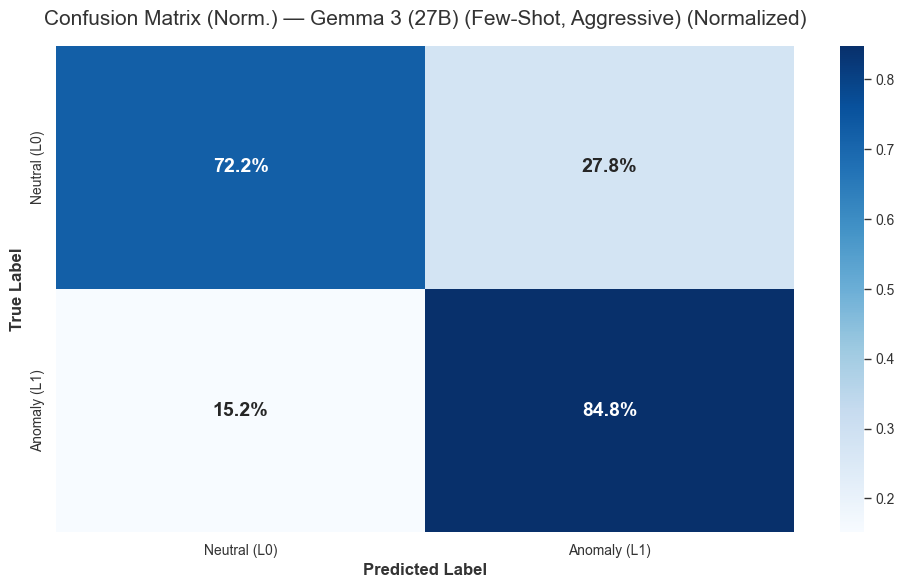

2026-03-13 20:29:06,749 - INFO - 💾 Saved confusion matrix to C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_confusion_matrix.png


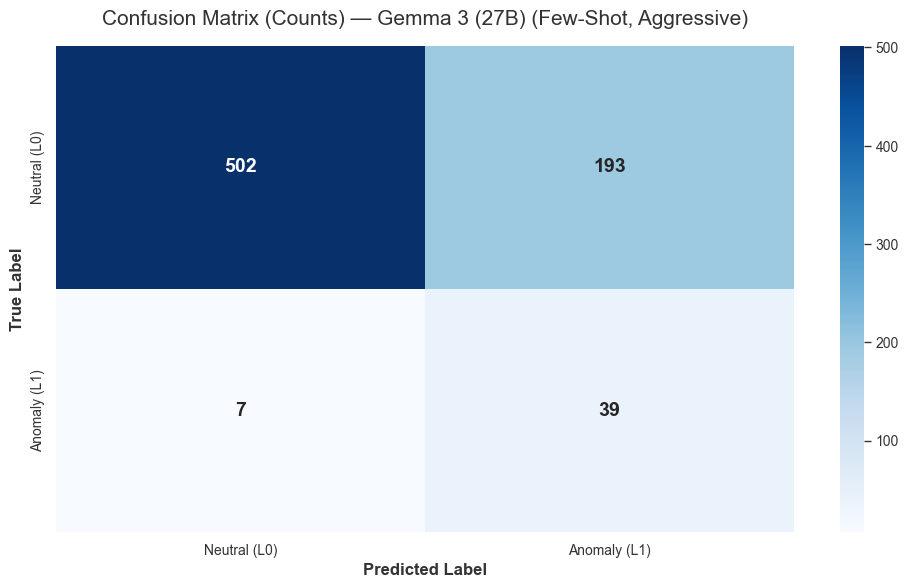


📋 CLASSIFICATION REPORT — Gemma 3 (27B) (Few-Shot, Aggressive)
              precision    recall  f1-score   support

 Neutral (0)     0.9862    0.7223    0.8339       695
    Bias (1)     0.1681    0.8478    0.2806        46

    accuracy                         0.7301       741
   macro avg     0.5772    0.7851    0.5572       741
weighted avg     0.9355    0.7301    0.7995       741



In [8]:
# ==========================================
# Výběr nejlepšího LLM modelu podle AUPRC na aggressive filtru
# ==========================================
df_llm_only = df_llm_metrics[
    (df_llm_metrics['strategy'] != 'dummy') & 
    (df_llm_metrics['filter'] == 'aggressive')
].copy()

best_llm_row = df_llm_only.sort_values('auprc', ascending=False).iloc[0]
best_strategy = best_llm_row['strategy']
best_model_base = best_llm_row['model_base']

# Najdi odpovídající predikční sloupec
for m in MODELS_TO_TEST:
    if m['display_name'] == best_model_base:
        best_llm_col = f"pred_{m['id']}_{best_strategy}"
        break

print(f"🏆 Best LLM (Aggressive, by AUPRC): {best_llm_row['model']}")
print(f"   Sloupec: {best_llm_col}")

# Filtrujeme na aggressive POS + validní predikce
aggressive_mask = df_results['pos'].isin(config.POS_ALLOWED_AGGRESSIVE)
df_valid = df_results[aggressive_mask].dropna(subset=[best_llm_col]).copy()
y_true = df_valid['true_label'].astype(int).values
y_pred = df_valid[best_llm_col].astype(int).values

print(f"   Tokenů: {len(df_valid)}, L1: {y_true.sum()}")

# ==========================================
# Confusion Matrix (Normalized)
# ==========================================
visualization.plot_confusion_matrix_heatmap(
    y_true, y_pred, normalize=True,
    title=f"Matice záměn (norm.) — {best_llm_row['model']}",
    save_path=config.RESULTS_DIR / "M3_S1_confusion_matrix_norm.png"
)

# ==========================================
# Confusion Matrix (Raw Counts)
# ==========================================
visualization.plot_confusion_matrix_heatmap(
    y_true, y_pred, normalize=False,
    title=f"Matice záměn (počty) — {best_llm_row['model']}",
    save_path=config.RESULTS_DIR / "M3_S1_confusion_matrix.png"
)

# ==========================================
# Classification Report
# ==========================================
print("\n" + "=" * 60)
print(f"📋 CLASSIFICATION REPORT — {best_llm_row['model']}")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=['Neutrální (L0)', 'Bias/LJMPNIK (L1)'], digits=4))

## 8. Qualitative Analysis (Error Analysis)

Konkrétní příklady tokenů, které model nesprávně klasifikoval — False Positives (falešný poplach) a False Negatives (přehlédnutý bias).

### Embedding Projections (Error Analysis — Aggressive filtr)

Vizualizace chyb nejlepšího LLM modelu v embedding prostoru (aggressive filtr).
PCA, t-SNE a UMAP projekce testovacích embeddingů, obarvenou podle Ground Truth a kategorie predikce (TP, FP, TN, FN).

2026-03-13 20:29:10,381 - INFO - 1️⃣ Computing PCA...
2026-03-13 20:29:10,397 - INFO - 2️⃣ Computing t-SNE...
2026-03-13 20:29:14,490 - INFO - 3️⃣ Computing UMAP...



🔹 Vizualizace: PCA


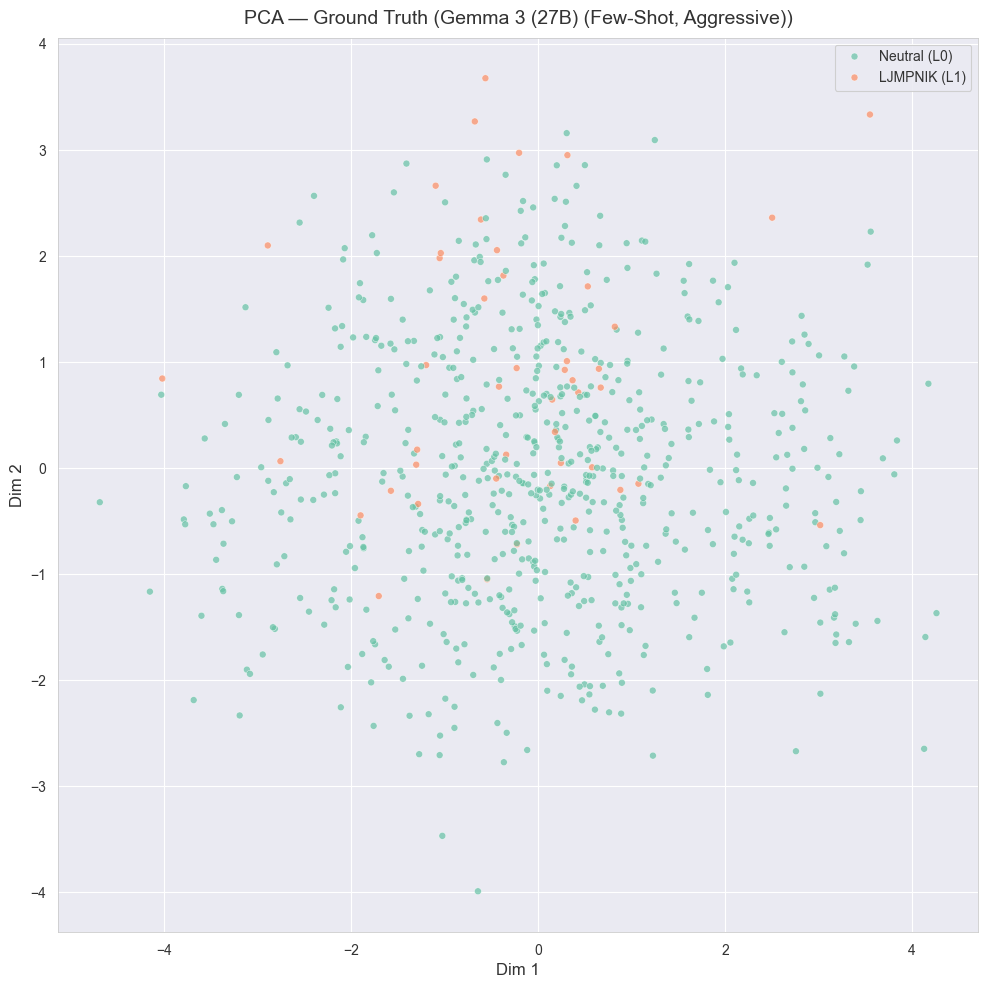

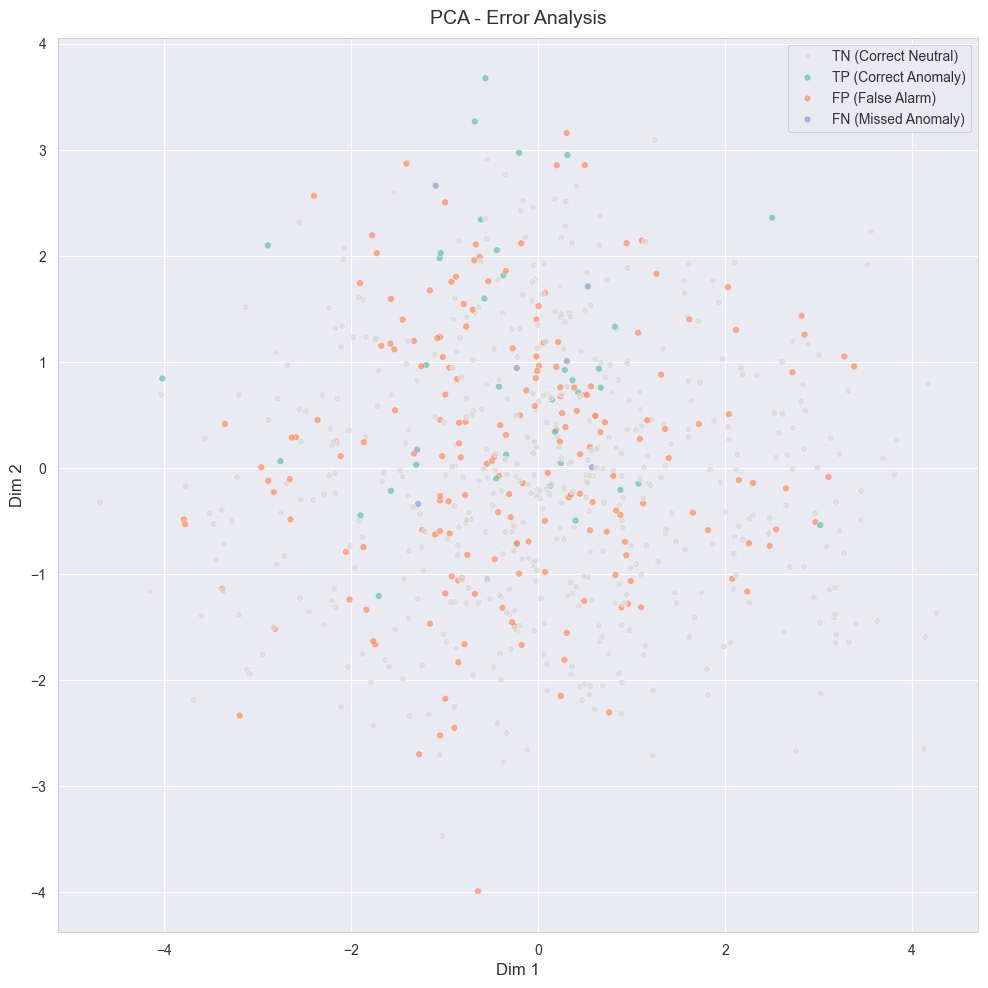


🔹 Vizualizace: t-SNE


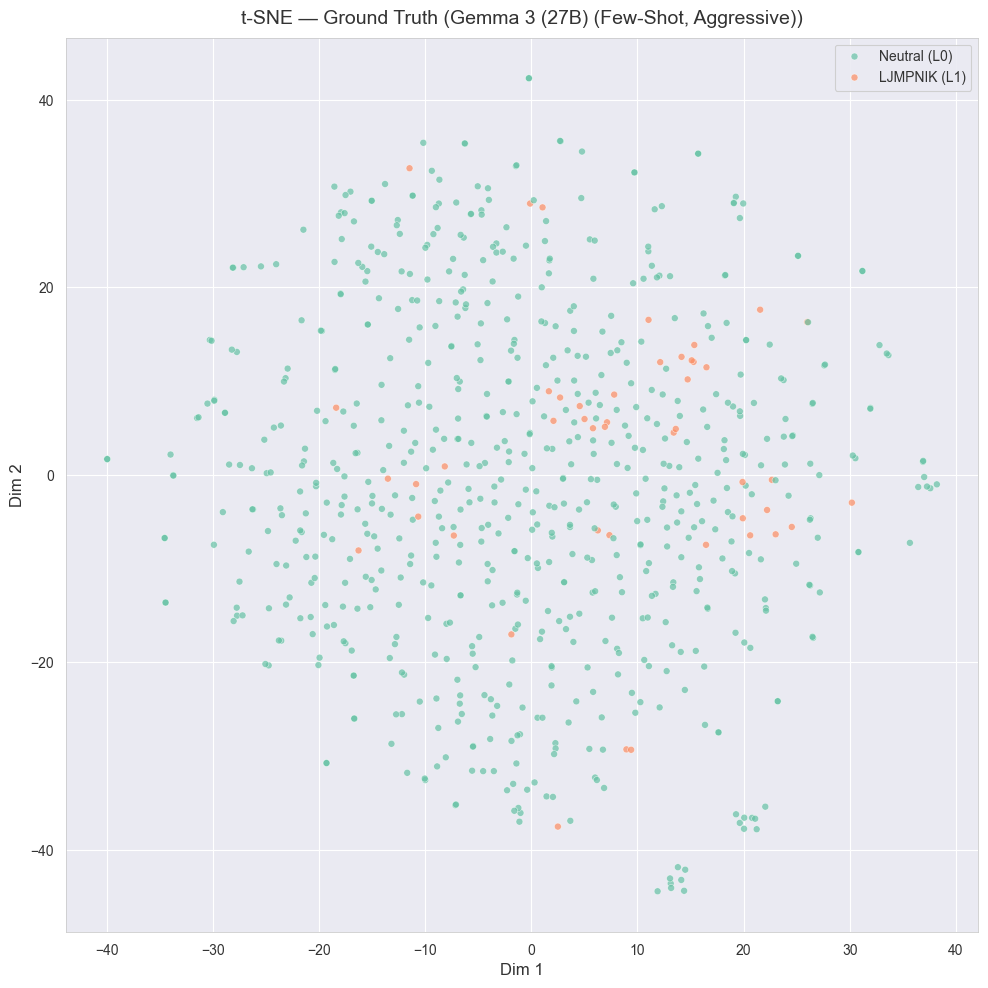

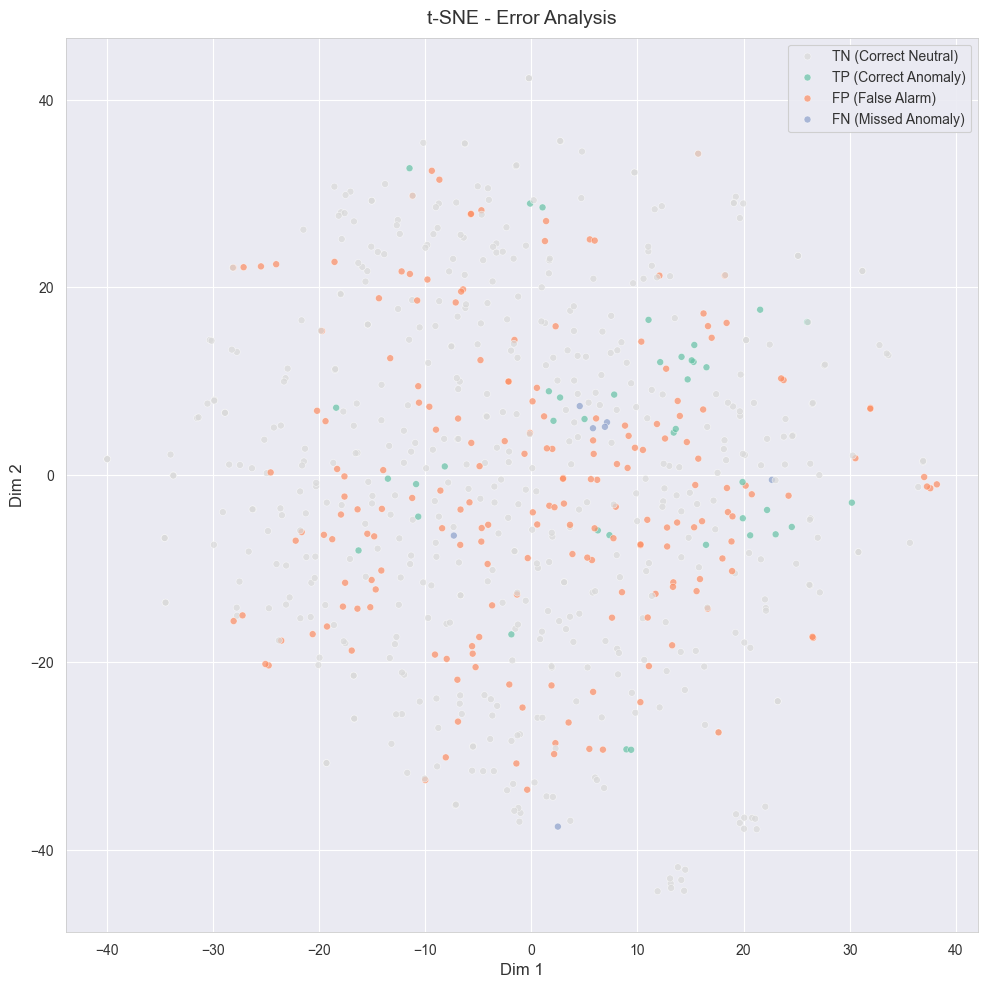


🔹 Vizualizace: UMAP


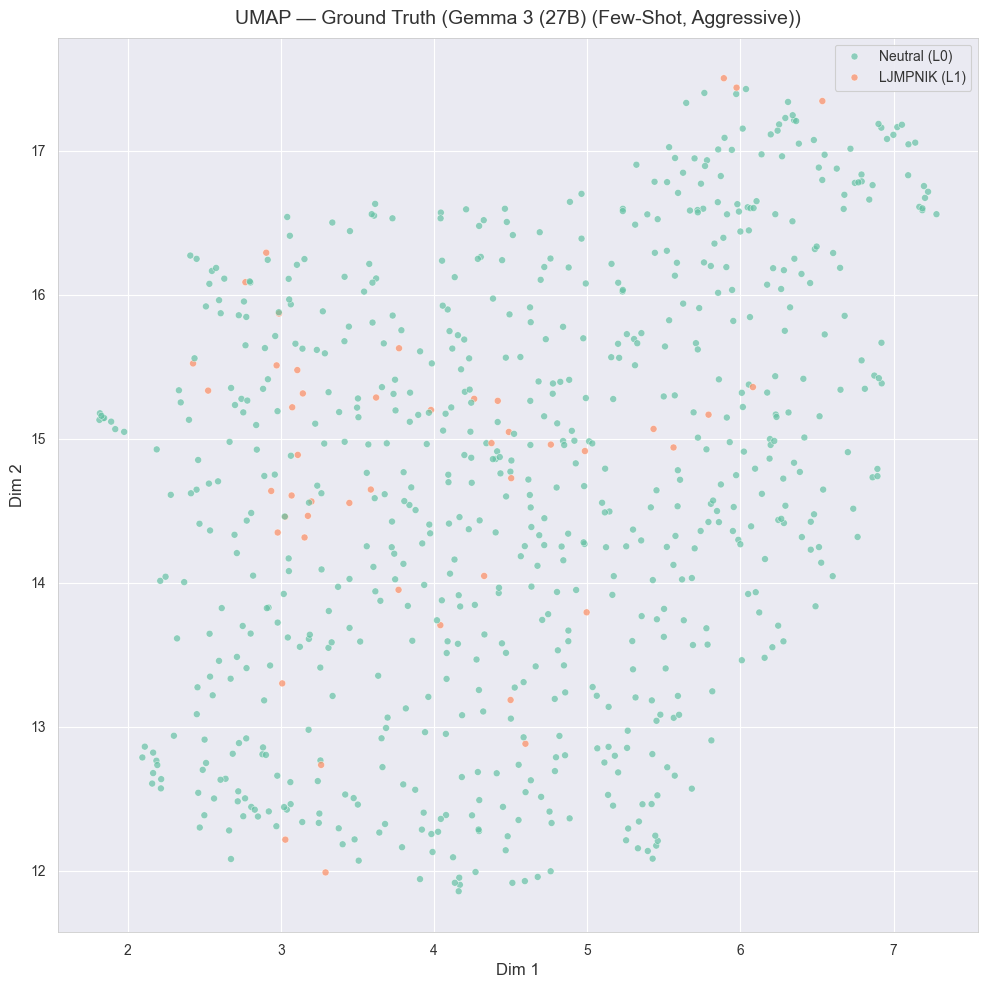

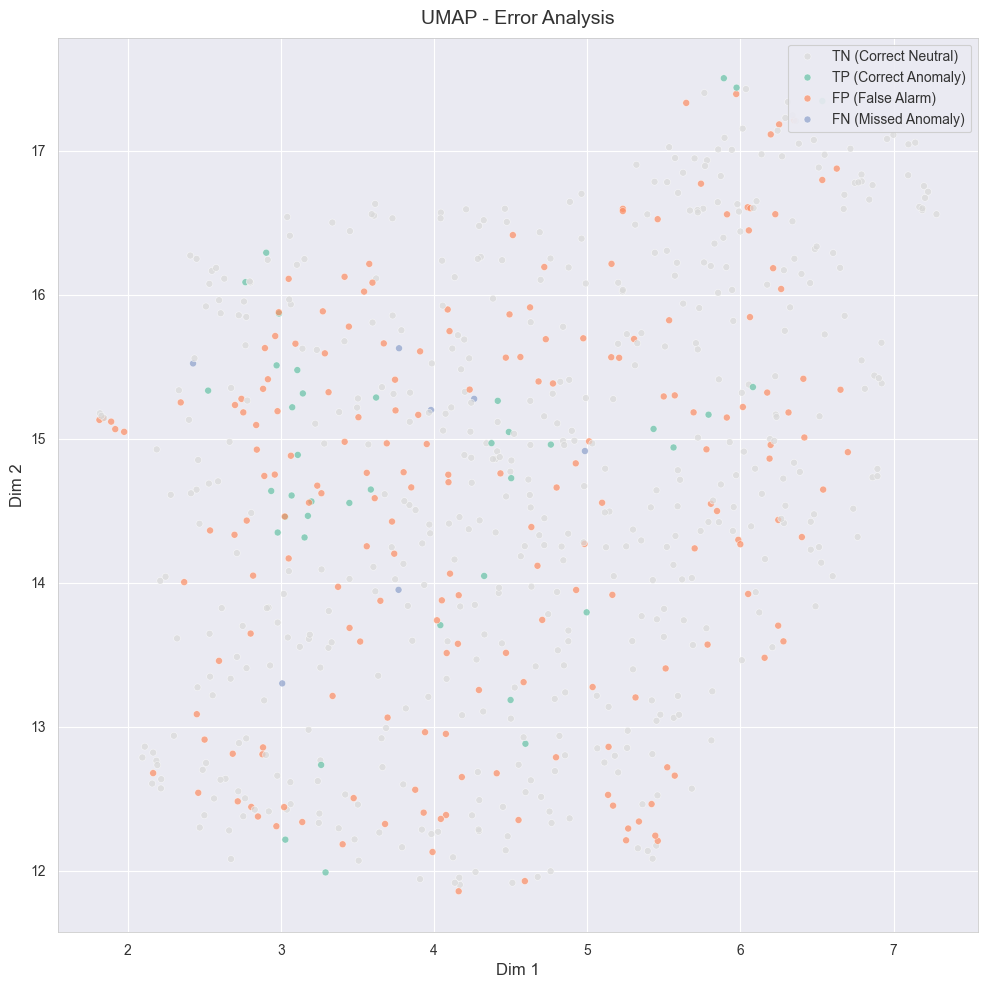


✅ Všechny projekce uloženy.


In [9]:
# ==========================================
# Embedding Projections — Error Analysis (Aggressive filtr)
# ==========================================
# Potřebujeme embeddingy odpovídající aggressive-filtrovaným tokenům
# data['X_test'] odpovídá filter_type='none', musíme filtrovat na aggressive
aggressive_idx = df_results['pos'].isin(config.POS_ALLOWED_AGGRESSIVE)
X_test_agg = data['X_test'][aggressive_idx.values]

# Compute PCA + t-SNE + UMAP projections
projs, idxs = visualization.compute_projections(
    X_test_agg, methods=['PCA', 't-SNE', 'UMAP'], random_state=42
)

y_viz = y_true[idxs]
y_pred_viz = y_pred[idxs]

for method_name, coords in projs.items():
    print(f"\n🔹 Vizualizace: {method_name}")
    
    # --- A) Ground Truth projection ---
    labels_gt = pd.Series(y_viz).map({0: 'Neutrální (L0)', 1: 'Bias/LJMPNIK (L1)'})
    
    visualization.plot_embedding_projection(
        coords,
        labels_gt,
        palette={'Neutrální (L0)': config.COLORS['l0'], 'Bias/LJMPNIK (L1)': config.COLORS['l1']},
        title=f"{method_name} — Skutečné třídy ({best_llm_row['model']})",
        hue_order=['Neutrální (L0)', 'Bias/LJMPNIK (L1)'],
        save_path=config.RESULTS_DIR / f"M3_S1_{method_name}_ground_truth.png"
    )
    
    # --- B) Error Analysis projection (TP, FP, TN, FN) ---
    visualization.plot_error_analysis_projection(
        coords, y_viz, y_pred_viz,
        method_name=method_name,
        save_path=config.RESULTS_DIR / f"M3_S1_{method_name}_error_analysis.png"
    )

print("\n✅ Všechny projekce uloženy.")

In [10]:
# ==========================================
# Qualitative Error Analysis (Aggressive filtr)
# ==========================================
df_qual = df_valid[['document_id', 'sentence_id', 'form', 'pos', 'sentence_context', 'true_label']].copy()
df_qual['pred_label'] = y_pred

# Kategorizace predikce (TP / TN / FP / FN)
conds = [
    (df_qual['true_label'] == 1) & (df_qual['pred_label'] == 1),
    (df_qual['true_label'] == 0) & (df_qual['pred_label'] == 0),
    (df_qual['true_label'] == 0) & (df_qual['pred_label'] == 1),
    (df_qual['true_label'] == 1) & (df_qual['pred_label'] == 0),
]
df_qual['category'] = np.select(conds, ['TP', 'TN', 'FP', 'FN'], default='UNKNOWN')

# Distribuce kategorií
print(f"📊 Distribuce kategorií predikce ({best_llm_row['model']}, Aggressive filtr):")
display(df_qual['category'].value_counts().to_frame('count'))

# --- False Positives ---
df_fp = df_qual[df_qual['category'] == 'FP'].copy()
print(f"\n❌ FALSE POSITIVES — Model označil neutrální slovo jako bias ({len(df_fp)} tokenů):")
display(df_fp[['form', 'pos', 'sentence_context', 'document_id']].head(10))

# --- False Negatives ---
df_fn = df_qual[df_qual['category'] == 'FN'].copy()
print(f"\n❌ FALSE NEGATIVES — Model přehlédl biased slovo ({len(df_fn)} tokenů):")
display(df_fn[['form', 'pos', 'sentence_context', 'document_id']].head(10))

# Uložení
qual_path = config.RESULTS_DIR / "M3_S1_Qualitative_Analysis.csv"
df_qual.to_csv(qual_path, index=False)
print(f"\n💾 Qualitative analysis uložena: {qual_path}")

📊 Distribuce kategorií predikce (Gemma 3 (27B) (Few-Shot, Aggressive), Aggressive filtr):


,count
category,
TN,502
FP,193
TP,39
FN,7



❌ FALSE POSITIVES — Model označil neutrální slovo jako bias (193 tokenů):


,form,pos,sentence_context,document_id
0,Tempo,NOUN,Tempo výstavby nových bytů je žalostné .,gold_doc_0003
1,výstavby,NOUN,Tempo výstavby nových bytů je žalostné .,gold_doc_0003
2,nových,ADJ,Tempo výstavby nových bytů je žalostné .,gold_doc_0003
7,Produktivita,NOUN,Produktivita práce v některých odvětvích je vš...,gold_doc_0007
8,práce,NOUN,Produktivita práce v některých odvětvích je vš...,gold_doc_0007
11,odvětvích,NOUN,Produktivita práce v některých odvětvích je vš...,gold_doc_0007
16,Úroveň,NOUN,Úroveň čistoty ve vozidlech je otřesná .,gold_doc_0010
17,čistoty,NOUN,Úroveň čistoty ve vozidlech je otřesná .,gold_doc_0010
19,vozidlech,NOUN,Úroveň čistoty ve vozidlech je otřesná .,gold_doc_0010
24,selhání,NOUN,Naprosté selhání dozorových orgánů vedlo k opo...,gold_doc_0011



❌ FALSE NEGATIVES — Model přehlédl biased slovo (7 tokenů):


,form,pos,sentence_context,document_id
126,bikesharing,NOUN,"Dodal , že firma se chce zaměřit na jednání s ...",gold_doc_0056
238,pendlerů,NOUN,Stále nedořešená je otázka pendlerů a jejich z...,gold_doc_0084
272,konsolidace,NOUN,Růst cen energií se zastavil a nastoupila nová...,gold_doc_0088
279,inkongruence,NOUN,Byl zjištěn nečekaný případ inkongruence nález...,gold_doc_0091
303,desítky,NOUN,"Byly nalezeny desítky artefaktů , které pocház...",gold_doc_0121
629,zhruba,ADV,Město při plánování průmyslového parku o rozlo...,gold_doc_0242
886,nearshoring,NOUN,Vedení průmyslových firem považuje nearshoring...,gold_doc_0334



💾 Qualitative analysis uložena: C:\Users\dobes\Documents\UniversityCodingProject_10-02-26\ThesisCoding\results\M3_S1_Qualitative_Analysis.csv
